In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [ ]:
df = pd.read_csv('Crop_recommendation.csv')

In [ ]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 2200
Jumlah kolom : 8


In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=10.0,
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Logistic Regression: {accuracy * 100:.2f}%")
print("-" * 50)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Akurasi Logistic Regression: 97.05%
--------------------------------------------------

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


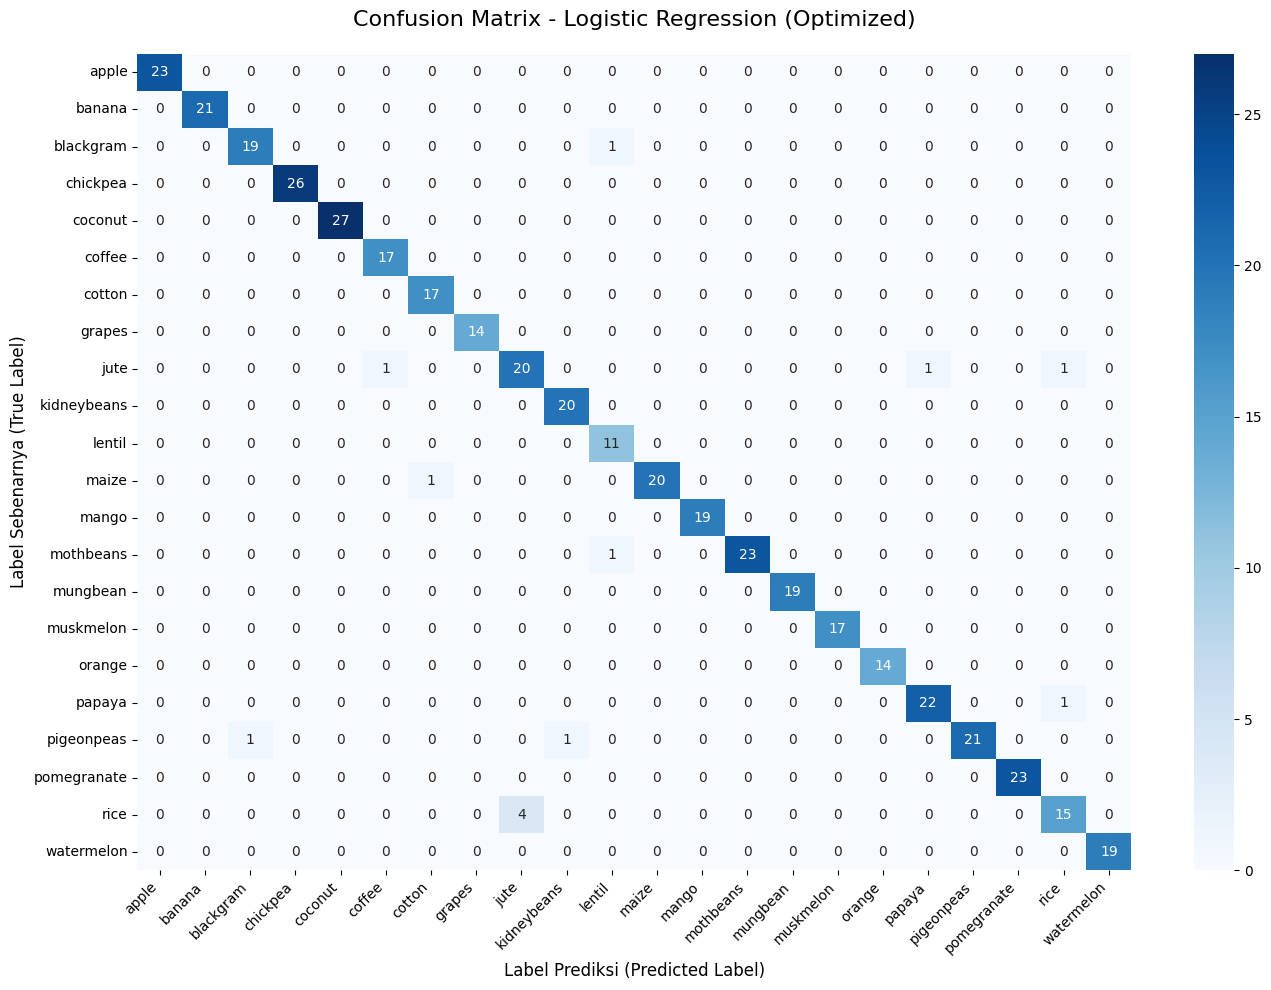

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
labels = np.unique(y)

plt.figure(figsize=(14, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression (Optimized)', fontsize=16, pad=20)
plt.ylabel('Label Sebenarnya (True Label)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define the pipeline using StandardScaler and LogisticRegression
pipeline = make_pipeline(StandardScaler(), LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=10.0,
    max_iter=2000,
    random_state=42
))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(pipeline, X, y, cv=kf, scoring='accuracy', return_train_score=True)

train_scores = cv_results['train_score']
val_scores = cv_results['test_score']

print("\n=== HASIL CROSS VALIDATION ===")
for i in range(5):
    print(f"Fold ke-{i+1} | Akurasi Training: {train_scores[i]*100:.2f}% | Akurasi Validasi: {val_scores[i]*100:.2f}%")

rata_train = train_scores.mean() * 100
rata_val = val_scores.mean() * 100
print(f"Rata-rata Akurasi Training : {rata_train:.2f}%")
print(f"Rata-rata Akurasi Validasi : {rata_val:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


=== HASIL CROSS VALIDATION ===
Fold ke-1 | Akurasi Training: 98.92% | Akurasi Validasi: 97.05%
Fold ke-2 | Akurasi Training: 98.75% | Akurasi Validasi: 97.73%
Fold ke-3 | Akurasi Training: 98.35% | Akurasi Validasi: 98.41%
Fold ke-4 | Akurasi Training: 98.81% | Akurasi Validasi: 97.73%
Fold ke-5 | Akurasi Training: 98.35% | Akurasi Validasi: 98.41%
Rata-rata Akurasi Training : 98.64%
Rata-rata Akurasi Validasi : 97.86%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
pipeline.fit(X, y)

joblib.dump(pipeline, 'model_pertanian_lr2.pkl')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


['model_pertanian_lr2.pkl']